# Preprocessing Wikipedia Summarization
Notebook ini melokalisasi SELURUH preprocessing dalam satu tempat. Notebook training
extractive & abstractive cukup memanggil `data_final_preprocessing.csv` tanpa preprocessing lagi.

**Dua output:**
- `data_no_preprocessing.csv` — hasil merge mentah (untuk Skenario 3: tanpa preprocessing)
- `data_final_preprocessing.csv` — hasil preprocessing lengkap (untuk training & skenario lain)

**Urutan:** merge → dedup → bersihkan struktur → normalisasi → saring → pecah kalimat → simpan.


---
## 1. Import

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

## 2. Merge Data & Buat ID Global

In [4]:
BASE = '/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization'

files = {
    'sejarah':  f'{BASE}/data_sejarah.csv',
    'artis':    f'{BASE}/data_artis.csv',
    'kuliner':  f'{BASE}/data_kuliner.csv',
    'arts':     f'{BASE}/data_arts.csv',
    'biografi': f'{BASE}/data_biografi.csv',
    'sains':    f'{BASE}/data_sains.csv',
    'tech':     f'{BASE}/data_tech.csv',
}

KEEP = ['id', 'title', 'category', 'article_text',
        'body_word_count', 'lead_paragraph', 'lead_word_count']

dfs = []
for kategori, path in files.items():
    d = pd.read_csv(path, encoding='utf-8-sig')
    d = d[[c for c in KEEP if c in d.columns]]
    dfs.append(d)

merged = pd.concat(dfs, ignore_index=True)
merged.insert(0, 'global_id', [f'doc_{i:05d}' for i in range(len(merged))])

print(f'Total setelah merge: {len(merged)} baris')
print(merged['category'].value_counts().to_string())

Total setelah merge: 13444 baris
category
sejarah     2000
biografi    2000
arts        2000
tech        2000
artis       1984
kuliner     1974
sains       1486


## 3. Simpan Versi Tanpa Preprocessing (untuk Skenario 3)

In [5]:
merged.to_csv('data_no_preprocessing.csv', index=False, encoding='utf-8-sig')
print(f'Tersimpan: data_no_preprocessing.csv ({len(merged)} baris)')

Tersimpan: data_no_preprocessing.csv (13444 baris)


## 4. Cek Duplikasi Judul

In [6]:
merged['_tn'] = merged['title'].astype(str).str.lower().str.strip()

n_dup = merged.duplicated('_tn', keep=False).sum()
n_unik = merged[merged.duplicated('_tn', keep=False)]['_tn'].nunique()

print(f'Baris terlibat duplikat judul : {n_dup}')
print(f'Judul unik yang duplikat      : {n_unik}')

Baris terlibat duplikat judul : 1362
Judul unik yang duplikat      : 672


## 5. Cek Overlap Judul Artis & Biografi

In [7]:
artis    = set(merged.loc[merged.category == 'artis', '_tn'])
biografi = set(merged.loc[merged.category == 'biografi', '_tn'])
overlap  = artis & biografi

print(f'Overlap judul artis <-> biografi: {len(overlap)}')
if overlap:
    print('Contoh:', list(overlap)[:5])

Overlap judul artis <-> biografi: 13
Contoh: ['lucky hakim', 'arya wedakarna', 'paundrakarna', 'mayangsari', 'rahayu saraswati']


## 6. Hapus Duplikasi

In [8]:
before = len(merged)

drop_idx = merged[(merged.category == 'artis') & (merged['_tn'].isin(overlap))].index
merged = merged.drop(index=drop_idx)
merged = merged.drop_duplicates('_tn', keep='first').reset_index(drop=True)

print(f'Sebelum : {before} baris')
print(f'Sesudah : {len(merged)} baris')
print(f'Dibuang : {before - len(merged)} baris')

Sebelum : 13444 baris
Sesudah : 12754 baris
Dibuang : 690 baris


## 7. Pembersihan Teks
Langkah 5-12: hapus referensi, heading, URL, template; normalisasi kutip & dash;
rapikan spasi; lowercasing; hapus karakter non-alfanumerik.

In [9]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'\[\d+\]', '', text)
    text = re.sub(r'={2,}.*?={2,}', '', text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\{\{.*?\}\}', '', text, flags=re.DOTALL)
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    text = text.replace('\u2013', '-').replace('\u2014', '-')
    text = re.sub(r'\s+', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s,.]', '', text)
    return text.strip()

merged['article_text'] = merged['article_text'].apply(clean_text)
merged['lead_paragraph'] = merged['lead_paragraph'].apply(clean_text)
print('Pembersihan teks selesai (langkah 5-12).')
print(f'Contoh: {merged["article_text"].iloc[0][:200]}')

Pembersihan teks selesai (langkah 5-12).
Contoh: menurut mohammad yamin, ppki didirikan pada 18 agustus 1945. namun, hal ini dibantah oleh a. b. kusuma yang berhasil memperoleh dokumen otentik badan penyelidik usahausaha persiapan kemerdekaan dan pp


## 8. Normalisasi Judul

In [10]:
merged['title'] = merged['title'].astype(str).str.strip().str.title()
print('Normalisasi judul selesai.')
print(merged['title'].head(3).to_string())

Normalisasi judul selesai.
0    Panitia Persiapan Kemerdekaan Indonesia
1                        Peristiwa Andi Azis
2                          Sejarah Indonesia


## 9. Filter Artikel Pendek

In [11]:
merged['body_word_count'] = merged['article_text'].str.split().str.len()
merged['lead_word_count'] = merged['lead_paragraph'].str.split().str.len()

MIN_WORDS = 100
before = len(merged)
merged = merged[merged['body_word_count'] >= MIN_WORDS].reset_index(drop=True)

print(f'Sebelum filter: {before} baris')
print(f'Sesudah filter: {len(merged)} baris')
print(merged['body_word_count'].describe().round(0).to_string())

Sebelum filter: 12754 baris
Sesudah filter: 12644 baris
count    12644.0
mean       452.0
std        484.0
min        100.0
25%        182.0
50%        302.0
75%        538.0
max      11947.0


## 10. Pemecahan Kalimat

In [12]:
def split_sentences(text):
    sentences = sent_tokenize(str(text))
    return [s.strip() for s in sentences if len(s.split()) >= 4]

merged['sentences'] = merged['article_text'].apply(lambda t: ' ||| '.join(split_sentences(t)))

print('Pemecahan kalimat selesai.')
print(f'Jumlah kalimat artikel pertama: {len(merged["sentences"].iloc[0].split(" ||| "))}')

Pemecahan kalimat selesai.
Jumlah kalimat artikel pertama: 19


---
## 11. Visualisasi Dataset

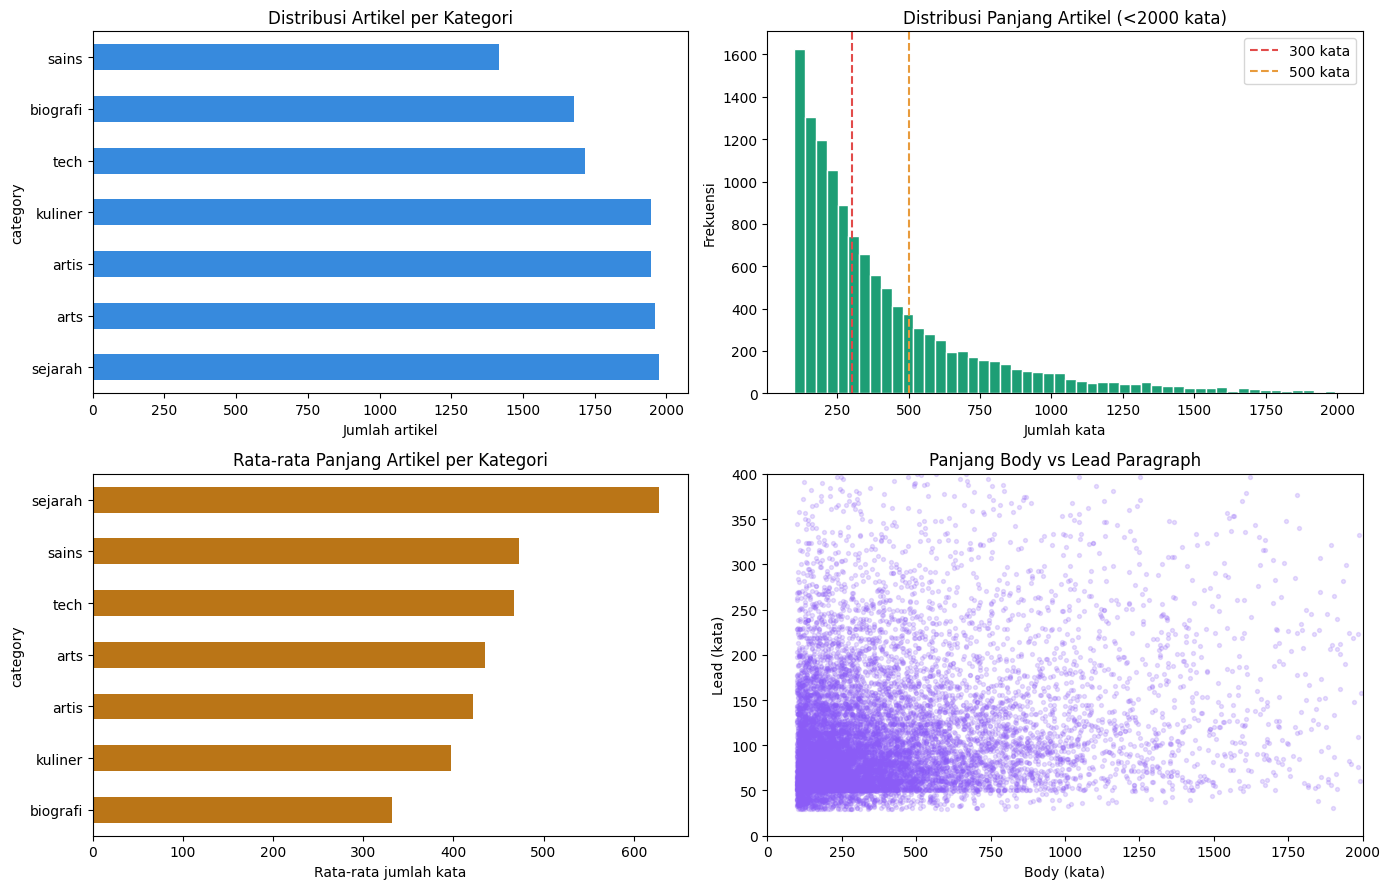

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

merged['category'].value_counts().plot(kind='barh', ax=ax[0,0], color='#378ADD')
ax[0,0].set_title('Distribusi Artikel per Kategori')
ax[0,0].set_xlabel('Jumlah artikel')

ax[0,1].hist(merged['body_word_count'][merged['body_word_count'] < 2000],
             bins=50, color='#1D9E75', edgecolor='white')
ax[0,1].set_title('Distribusi Panjang Artikel (<2000 kata)')
ax[0,1].set_xlabel('Jumlah kata'); ax[0,1].set_ylabel('Frekuensi')
ax[0,1].axvline(300, color='#E24B4A', linestyle='--', label='300 kata')
ax[0,1].axvline(500, color='#E89B3C', linestyle='--', label='500 kata')
ax[0,1].legend()

merged.groupby('category')['body_word_count'].mean().sort_values().plot(
    kind='barh', ax=ax[1,0], color='#BA7517')
ax[1,0].set_title('Rata-rata Panjang Artikel per Kategori')
ax[1,0].set_xlabel('Rata-rata jumlah kata')

ax[1,1].scatter(merged['body_word_count'], merged['lead_word_count'],
                alpha=0.2, s=8, color='#8B5CF6')
ax[1,1].set_title('Panjang Body vs Lead Paragraph')
ax[1,1].set_xlabel('Body (kata)'); ax[1,1].set_ylabel('Lead (kata)')
ax[1,1].set_xlim(0, 2000); ax[1,1].set_ylim(0, 400)

plt.tight_layout(); plt.show()

## 12. Ringkasan & Distribusi Kelompok Panjang

Ringkasan dataset final:
  Total kategori : 7
  Total artikel  : 12644
  Rata-rata kata : 452
  Median kata    : 302


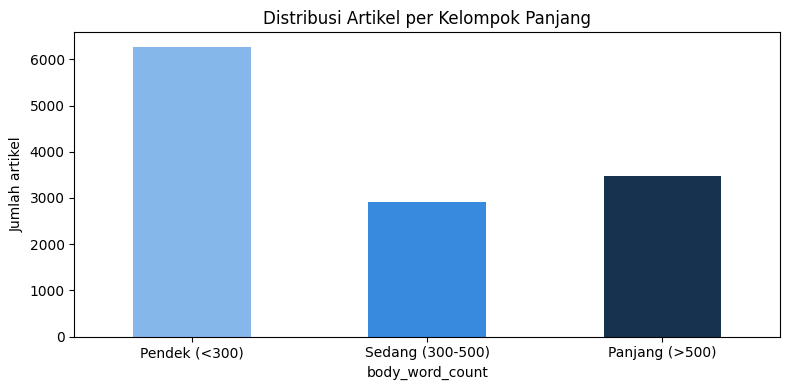

In [14]:
print('Ringkasan dataset final:')
print(f'  Total kategori : {merged["category"].nunique()}')
print(f'  Total artikel  : {len(merged)}')
print(f'  Rata-rata kata : {merged["body_word_count"].mean():.0f}')
print(f'  Median kata    : {merged["body_word_count"].median():.0f}')

def length_group(wc):
    if wc < 300: return 'Pendek (<300)'
    elif wc <= 500: return 'Sedang (300-500)'
    else: return 'Panjang (>500)'

grup = merged['body_word_count'].apply(length_group).value_counts()
grup = grup.reindex(['Pendek (<300)', 'Sedang (300-500)', 'Panjang (>500)'])

plt.figure(figsize=(8, 4))
grup.plot(kind='bar', color=['#85B7EB', '#378ADD', '#16324f'])
plt.title('Distribusi Artikel per Kelompok Panjang')
plt.ylabel('Jumlah artikel'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

---
## 13. Simpan Hasil Final Preprocessing

In [15]:
final_cols = ['global_id', 'id', 'title', 'category', 'article_text',
              'body_word_count', 'lead_paragraph', 'lead_word_count', 'sentences']

simpan = merged[[c for c in final_cols if c in merged.columns]]
simpan.to_csv('data_final_preprocessing.csv', index=False, encoding='utf-8-sig')

print(f'Tersimpan: data_final_preprocessing.csv ({len(simpan)} baris)')
print(f'Kolom: {list(simpan.columns)}')

Tersimpan: data_final_preprocessing.csv (12644 baris)
Kolom: ['global_id', 'id', 'title', 'category', 'article_text', 'body_word_count', 'lead_paragraph', 'lead_word_count', 'sentences']
